# Churn EDA (Beginner‑Friendly, R)

This notebook is designed for **beginners to R and data analysis**.

It reads `./data/churn.csv` and walks through common exploratory steps with **lots of comments** and very clear, explicit R code.

**How to run**
1. Make sure the file exists at `./data/churn.csv`.
2. Run each cell from top to bottom.
3. Feel free to modify the **Parameters** section and re‑run the plots.


## 1) Setup – install and load packages
We will use:
- `tidyverse` for data wrangling (read/write, filtering, grouping) and plotting (`ggplot2`).
- `janitor` to clean column names (make them simple and consistent).
- `skimr` to get a quick, readable overview of the data.
- `plotly` for basic interactivity on top of ggplot.

> If a package is missing, we install it from CRAN. In a conda/mamba environment you can also install packages via conda‑forge.

See also:
- requireNamespace() — R manual: https://stat.ethz.ch/R-manual/R-devel/library/base/html/namespace.html
- nstall.packages() — R manual: https://stat.ethz.ch/R-manual/R-devel/library/utils/html/install.packages.html
- library() — R manual: https://stat.ethz.ch/R-manual/R-devel/library/base/html/library.html
- tidyverse overview: https://www.tidyverse.org/packages/
- ggplot2 theme_set() / theme_minimal() — https://ggplot2.tidyverse.org/reference/theme.html


> #### See also
> - [`requireNamespace()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/namespace.html)
> - [`install.packages()`](https://stat.ethz.ch/R-manual/R-devel/library/utils/html/install.packages.html)
> - [`library()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/library.html)
> - **tidyverse** overview: https://www.tidyverse.org/packages/
> - **ggplot2** theme docs: https://ggplot2.tidyverse.org/reference/theme.html


In [1]:

# ------------------------------
# Setup: install and load packages
# ------------------------------

# Helper function to install a package only if it isn't already installed.
install_if_needed <- function(pkg_name) {
  # requireNamespace returns TRUE/FALSE based on package availability
  if (!requireNamespace(pkg_name, quietly = TRUE)) {
    install.packages(pkg_name)
  }
}

# List of packages we'll use in this notebook.
required_packages <- c("tidyverse", "janitor", "skimr", "plotly")

# Install missing packages.
for (p in required_packages) {
  install_if_needed(p)
}

# Load the packages into the current R session.
library(tidyverse)  # for data manipulation and plotting
library(janitor)    # for cleaning column names
library(skimr)      # for a quick data overview
library(plotly)     # for interactive plots based on ggplot

# Set a clean, minimalist theme for all ggplots
theme_set(ggplot2::theme_minimal(base_size = 14))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




> #### See also
> - [`file.exists()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/files.html)
> - [`read.csv()`](https://stat.ethz.ch/R-manual/R-devel/library/utils/html/read.table.html)
> - [`readr::read_csv()`](https://readr.tidyverse.org/reference/read_delim.html)
> - [`janitor::clean_names()`](https://sfirke.github.io/janitor/reference/clean_names.html)
> - [`tibble::as_tibble()`](https://tibble.tidyverse.org/reference/as_tibble.html)


## 2) Load the CSV (and make names easy to work with)
We expect the file at `./data/churn.csv`.
- We set `stringsAsFactors = FALSE` so text columns stay as plain character vectors.
- We use `clean_names()` to convert column names like `Total day minutes` → `total_day_minutes`.

See also:
- file.exists() — https://stat.ethz.ch/R-manual/R-devel/library/base/html/files.html
- read.csv() — https://stat.ethz.ch/R-manual/R-devel/library/utils/html/read.table.html
- readr::read_csv() — https://readr.tidyverse.org/reference/read_delim.html
- janitor::clean_names() — https://sfirke.github.io/janitor/reference/clean_names.html
- tibble::as_tibble() — https://tibble.tidyverse.org/reference/as_tibble.html

In [2]:

# ------------------------------
# Load the data from disk
# ------------------------------

csv_path <- "./data/churn.csv"

# Check that the file exists; if not, stop with an informative error.
if (!file.exists(csv_path)) {
  stop(paste("I cannot find the file at:", csv_path, "
Please make sure it exists relative to this notebook."))
}

# Read the CSV file into R. We use read.csv for familiarity; readr::read_csv is also good.
raw_data <- read.csv(csv_path, stringsAsFactors = FALSE)

# Clean column names (lowercase with underscores) and convert to a tibble for prettier printing.
churn <- raw_data %>%
  janitor::clean_names() %>%
  tibble::as_tibble()

# Print the cleaned column names and show the first few rows of data.
print(names(churn))
print(head(churn, 5))


 [1] "state"           "account_length"  "area_code"       "phone"          
 [5] "intl_plan"       "v_mail_plan"     "v_mail_message"  "day_mins"       
 [9] "day_calls"       "day_charge"      "eve_mins"        "eve_calls"      
[13] "eve_charge"      "night_mins"      "night_calls"     "night_charge"   
[17] "intl_mins"       "intl_calls"      "intl_charge"     "cust_serv_calls"
[21] "old_churn"       "churn"          
# A tibble: 5 × 22
  state account_length area_code phone    intl_plan v_mail_plan v_mail_message
  <chr>          <int>     <int> <chr>    <chr>     <chr>                <int>
1 KS               128       415 382-4657 no        yes                     25
2 OH               107       415 371-7191 no        yes                     26
3 NJ               137       415 358-1921 no        no                       0
4 OH                84       408 375-9999 yes       no                       0
5 OK                75       415 330-6626 yes       no                       0
# 

> #### See also
> - [`factor()` / `as.factor()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/factor.html)
> - [`names()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/names.html)
> - [`str()`](https://stat.ethz.ch/R-manual/R-devel/library/utils/html/str.html)


> #### See also
> - [`skimr::skim()`](https://docs.ropensci.org/skimr/reference/skim.html)
> - Printing tibbles: https://tibble.tidyverse.org/reference/print.html
> - Tip: In notebooks, `print(skimr::skim(df))` avoids rich-display hiccups.


## 3) Light cleaning: convert obvious categorical columns to factors
In many churn datasets, the **target** `churn` is Yes/No.
A few plan columns (e.g., `international_plan`, `voice_mail_plan`) are also Yes/No.
We will convert these columns to `factor` when they exist.

> If your column names differ, adjust the `maybe_factor_cols` list accordingly.

See also:
- factor() / as.factor() — https://stat.ethz.ch/R-manual/R-devel/library/base/html/factor.html
- names() — https://stat.ethz.ch/R-manual/R-devel/library/base/html/names.html
- str() — https://stat.ethz.ch/R-manual/R-devel/library/utils/html/str.html

> #### See also
> - [`dplyr::count()`](https://dplyr.tidyverse.org/reference/count.html)
> - [`dplyr::mutate()`](https://dplyr.tidyverse.org/reference/mutate.html)
> - [`ggplot()` / `aes()`](https://ggplot2.tidyverse.org/reference/ggplot.html)
> - [`geom_col()` / bar charts](https://ggplot2.tidyverse.org/reference/geom_bar.html)
> - [`geom_text()`](https://ggplot2.tidyverse.org/reference/geom_text.html)
> - [`scales::percent()`](https://scales.r-lib.org/reference/label_percent.html)
> - [`labs()` / `theme()`](https://ggplot2.tidyverse.org/reference/labs.html), https://ggplot2.tidyverse.org/reference/theme.html


In [3]:

# ------------------------------
# Convert certain columns to factors (categorical variables)
# ------------------------------

# Vector of columns we expect to be categorical
maybe_factor_cols <- c("churn", "international_plan", "voice_mail_plan", "state", "area_code")

# Loop over each column name and convert to factor if it exists in the data
for (col in maybe_factor_cols) {
  if (col %in% names(churn)) {
    churn[[col]] <- as.factor(churn[[col]])
  }
}

# Show a compact summary of column types
str(churn)


tibble [3,333 × 22] (S3: tbl_df/tbl/data.frame)
 $ state          : Factor w/ 51 levels "AK","AL","AR",..: 17 36 32 36 37 2 20 25 19 50 ...
 $ account_length : int [1:3333] 128 107 137 84 75 118 121 147 117 141 ...
 $ area_code      : Factor w/ 3 levels "408","415","510": 2 2 2 1 2 3 3 2 1 2 ...
 $ phone          : chr [1:3333] "382-4657" "371-7191" "358-1921" "375-9999" ...
 $ intl_plan      : chr [1:3333] "no" "no" "no" "yes" ...
 $ v_mail_plan    : chr [1:3333] "yes" "yes" "no" "no" ...
 $ v_mail_message : int [1:3333] 25 26 0 0 0 0 24 0 0 37 ...
 $ day_mins       : num [1:3333] 265 162 243 299 167 ...
 $ day_calls      : int [1:3333] 110 123 114 71 113 98 88 79 97 84 ...
 $ day_charge     : num [1:3333] 45.1 27.5 41.4 50.9 28.3 ...
 $ eve_mins       : num [1:3333] 197.4 195.5 121.2 61.9 148.3 ...
 $ eve_calls      : int [1:3333] 99 103 110 88 122 101 108 94 80 111 ...
 $ eve_charge     : num [1:3333] 16.78 16.62 10.3 5.26 12.61 ...
 $ night_mins     : num [1:3333] 245 254 163 197 1

> #### See also
> - Tidy-eval `.data[[...]]`: https://rlang.r-lib.org/reference/pronouns.html
> - [`group_by()` / `ungroup()`](https://dplyr.tidyverse.org/reference/group_by.html)
> - Stacked/filled bars: [`geom_col(position=)`](https://ggplot2.tidyverse.org/reference/geom_bar.html)
> - `scale_y_continuous(labels = scales::percent)`: https://ggplot2.tidyverse.org/reference/scale_continuous.html


## 4) Quick overview of the data
`skim()` gives us a compact summary: counts of missing values, basic statistics, etc.
This is useful to understand the overall data shape quickly.

In [4]:

# ------------------------------
# Quick, readable overview of the data
# ------------------------------

print(skimr::skim(churn))


── Data Summary ────────────────────────
                           Values
Name                       churn 
Number of rows             3333  
Number of columns          22    
_______________________          
Column type frequency:           
  character                4     
  factor                   3     
  numeric                  15    
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable n_missing complete_rate min max empty n_unique whitespace
1 phone                 0             1   8   8     0     3333          0
2 intl_plan             0             1   2   3     0        2          0
3 v_mail_plan           0             1   2   3     0        2          0
4 old_churn             0             1   5   6     0        2          0

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable n_missing complete_rate ordered n_u

## 5) Target distribution (How many churned vs not?)
A simple bar chart helps us see whether the classes are balanced.
If the classes are very imbalanced, it affects how we model and evaluate.

# A tibble: 2 × 3
  churn     n proportion
  <fct> <int>      <dbl>
1 False  2850      0.855
2 True    483      0.145


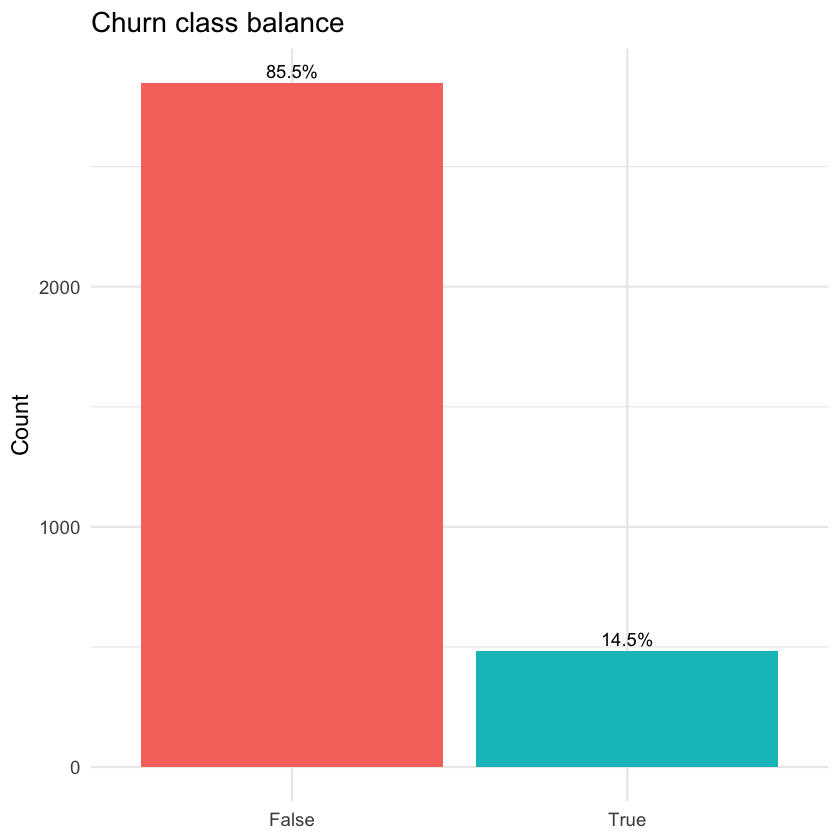

In [5]:

# ------------------------------
# Churn distribution: counts and proportions
# ------------------------------

# Check if 'churn' column exists
if (!("churn" %in% names(churn))) {
  stop("This dataset does not have a 'churn' column.")
}

# Count rows per churn level and compute proportion
churn_counts <- churn %>%
  dplyr::count(churn) %>%
  dplyr::mutate(proportion = n / sum(n))

print(churn_counts)

# Plot the counts with proportion labels
p_churn <- ggplot(churn_counts, aes(x = churn, y = n, fill = churn)) +
  geom_col() +
  geom_text(aes(label = scales::percent(proportion, accuracy = 0.1)), vjust = -0.4) +
  labs(title = "Churn class balance", x = NULL, y = "Count") +
  theme(legend.position = "none")

p_churn


> #### See also
> - [`geom_histogram()`](https://ggplot2.tidyverse.org/reference/geom_histogram.html)
> - Within-bin proportions via `position = "fill"` (see **position adjustments** in the link above)
> - Handling missing values: https://ggplot2.tidyverse.org/reference/ggplot2-package.html#handling-missing-values
> - Pre-binning helpers: [`pretty()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/pretty.html)


## 6) Categorical variables vs Churn (clustered and normalized bars)
We compare churn across categories for two common plan variables:
- **Counts**: number of customers in each combination.
- **Normalized**: within each category, the proportion of churn.

This helps us see differences that are not just due to raw counts.

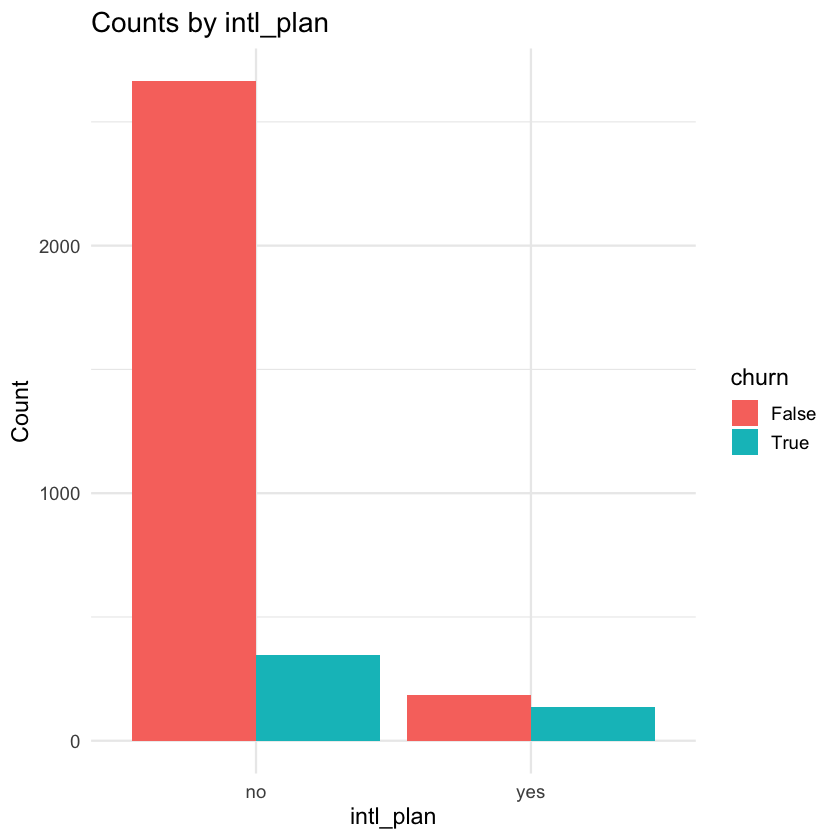

In [6]:

# ------------------------------
# Function to plot counts and proportions for a categorical variable vs churn
# ------------------------------

plot_cat_vs_churn <- function(data, cat_var_name) {
  # If the column doesn't exist, skip and return NULL
  if (!(cat_var_name %in% names(data))) return(NULL)
  if (!("churn" %in% names(data))) return(NULL)
  
  # Summarize counts by category and churn
  tab <- data %>%
    dplyr::count(.data[[cat_var_name]], churn) %>%
    dplyr::group_by(.data[[cat_var_name]]) %>%
    dplyr::mutate(prop_within_cat = n / sum(n)) %>%
    dplyr::ungroup()
  
  # Plot: counts per category by churn
  plot_counts <- ggplot(tab, aes(x = .data[[cat_var_name]], y = n, fill = churn)) +
    geom_col(position = "dodge") +
    labs(title = paste("Counts by", cat_var_name), x = cat_var_name, y = "Count")
  
  # Plot: proportion per category by churn
  plot_props <- ggplot(tab, aes(x = .data[[cat_var_name]], y = prop_within_cat, fill = churn)) +
    geom_col(position = "fill") +
    scale_y_continuous(labels = scales::percent) +
    labs(title = paste("Churn proportion within", cat_var_name), x = cat_var_name, y = "Proportion")
  
  # Return both plots
  list(counts = plot_counts, proportions = plot_props)
}

# Example usage for some plan columns
cat_vars <- c("intl_plan", "v_mail_plan")
plots_list <- lapply(cat_vars, function(v) plot_cat_vs_churn(churn, v))
names(plots_list) <- cat_vars

# Show counts plot for intl_plan, if present
plots_list$intl_plan$counts


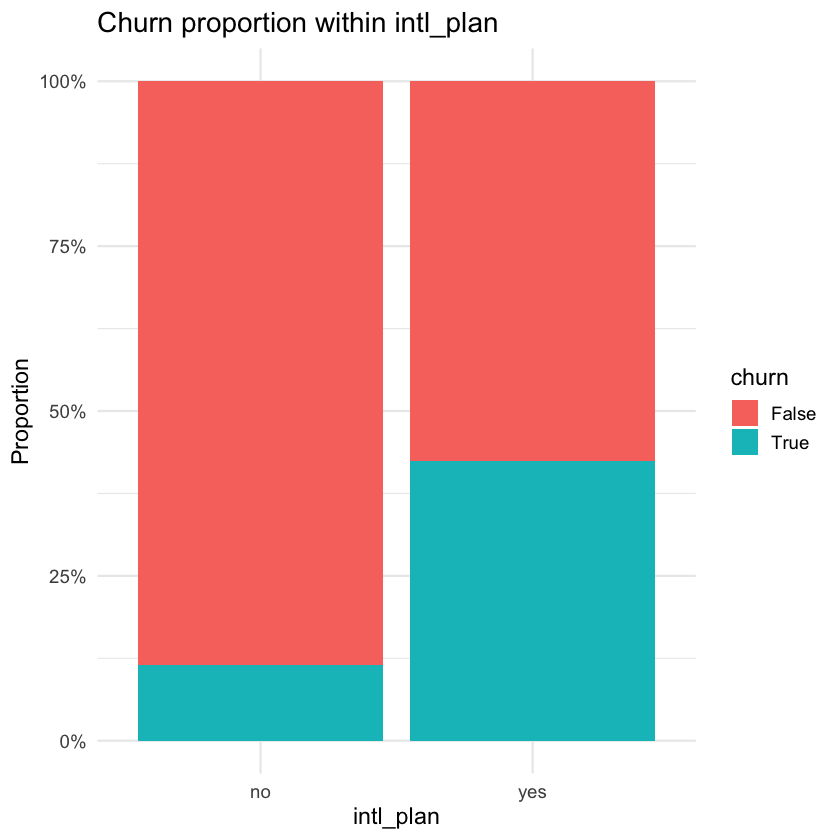

In [7]:

# Show proportions plot for intl_plan, if present
if (!is.null(plots_list$intl_plan)) {
  plots_list$intl_plan$proportions
}


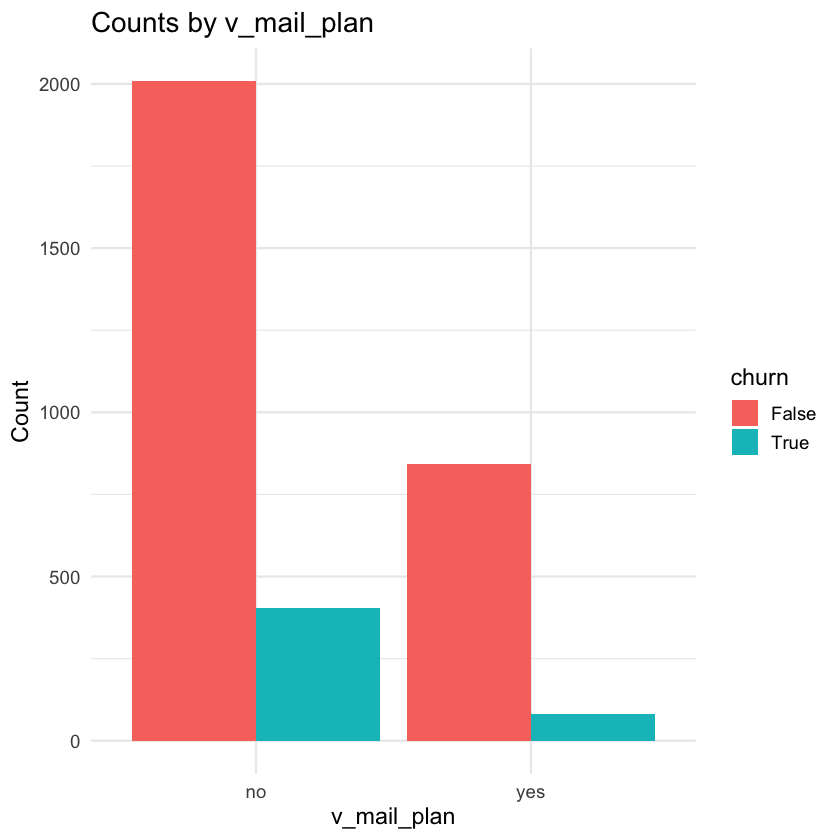

In [8]:

# Show counts and proportions for voice_mail_plan, if present
if (!is.null(plots_list$v_mail_plan)) {
  plots_list$v_mail_plan$counts
}


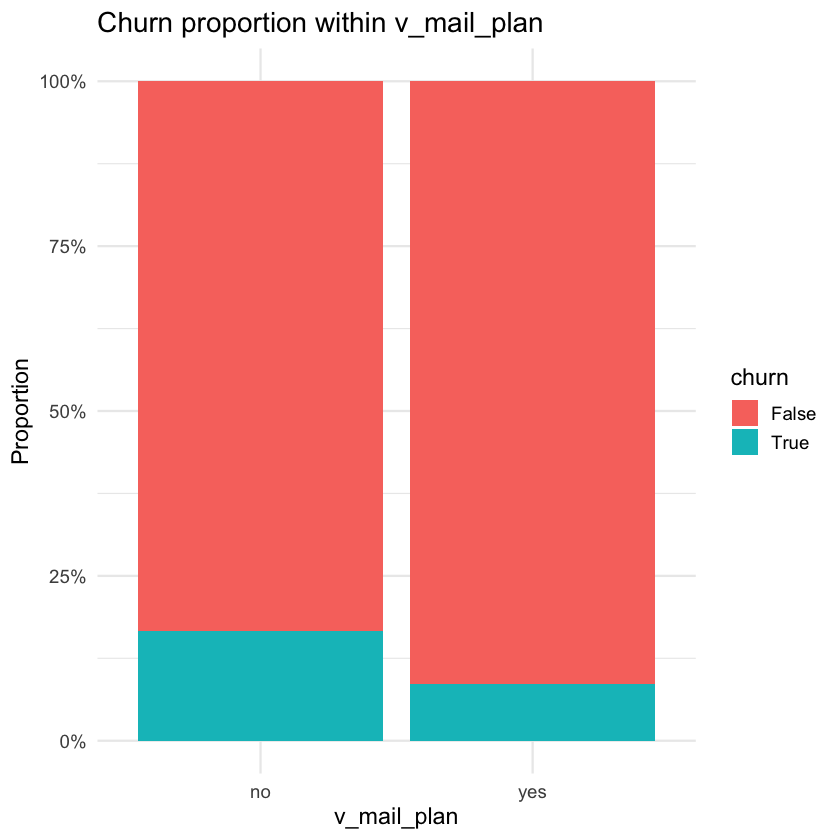

In [9]:

if (!is.null(plots_list$v_mail_plan)) {
  plots_list$v_mail_plan$proportions
}


## 7) Numeric variables vs Churn – paired histograms
Two histogram views of a numeric variable:
1. Counts (regular histogram)
2. Within-bin proportion: each bin shows the relative proportion of churn.

This helps highlight patterns beyond raw counts.

> #### See also
> - R syntax basics: https://stat.ethz.ch/R-manual/R-devel/library/base/html/Syntax.html
> - [`geom_abline()`](https://ggplot2.tidyverse.org/reference/geom_abline.html)


In [10]:

# ------------------------------
# Function to plot histograms (counts and normalized) for a numeric variable
# ------------------------------

plot_numeric_histograms <- function(data, num_var_name, bins = 30) {
  if (!(num_var_name %in% names(data))) return(NULL)
  if (!("churn" %in% names(data))) return(NULL)
  
  # Histogram of counts
  p_count <- ggplot(data, aes(x = .data[[num_var_name]], fill = churn)) +
    geom_histogram(bins = bins, position = "fill", alpha = 0.8, color = "white") +
  scale_y_continuous(labels = scales::percent) +
  labs(title = paste("Histogram of", num_var_name, "(within-bin proportion)"), x = num_var_name, y = "Proportion")
names(num_plots) <- num_examples

# Show the histograms for customer_service_calls
if (!is.null(num_plots$cust_serv_calls)) num_plots$cust_serv_calls$counts


ERROR: Error in parse(text = input): <text>:20:0: unexpected end of input
18: if (!is.null(num_plots$cust_serv_calls)) num_plots$cust_serv_calls$counts
19: 
   ^


> #### See also
> - [`dplyr::mutate()`](https://dplyr.tidyverse.org/reference/mutate.html)
> - [`ifelse()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/ifelse.html)
> - [`dplyr::count()`](https://dplyr.tidyverse.org/reference/count.html)
> - `geom_col(position = "fill")` + percent scale (see §1.6 links)


In [ ]:

if (!is.null(num_plots$cust_serv_calls)) num_plots$cust_serv_calls$normalized


In [ ]:

if (!is.null(num_plots$day_mins)) num_plots$day_mins$counts


> #### See also
> - [`geom_point()`](https://ggplot2.tidyverse.org/reference/geom_point.html)
> - [`geom_abline()`](https://ggplot2.tidyverse.org/reference/geom_abline.html)
> - [`plotly::ggplotly()`](https://plotly-r.com/ggplotly.html)
> - Save interactive widgets: [`htmlwidgets::saveWidget()`](https://www.htmlwidgets.org/reference/saveWidget.html)


In [ ]:

if (!is.null(num_plots$eve_mins)) num_plots$eve_mins$normalized


> #### See also
> - [`sapply()` / `is.numeric`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/lapply.html)
> - [`cor()`](https://stat.ethz.ch/R-manual/R-devel/library/stats/html/cor.html)
> - [`round()`](https://stat.ethz.ch/R-manual/R-devel/library/base/html/Round.html)


In [ ]:

if (!is.null(num_plots$eve_mins)) num_plots$eve_mins$counts


In [ ]:

if (!is.null(num_plots$eve_mins)) num_plots$eve_mins$normalized


## 8) Parameters – tweak and re‑run
You can adjust these values and re‑run the **Binning & Flags** and **Scatter** sections.
- `CSS_HIGH_THRESHOLD`: threshold for labeling high customer service calls.
- `LINE_INTERCEPT` and `LINE_SLOPE`: define a reference line in the scatter plot.

In [ ]:

# ------------------------------
# Parameters for binning and reference line
# ------------------------------

CSS_HIGH_THRESHOLD <- 4   # Threshold for 'high' customer service calls
LINE_INTERCEPT <- 400     # Intercept for the reference line (day vs evening)
LINE_SLOPE     <- -0.6    # Slope of the reference line


## 9) Binning & simple flag features
We derive simple features:
- `css_bin`: High vs Low customer service calls.
- `high_day_eve_flag`: whether a point is above the reference line in the Day vs Evening plot.

Then we see how churn proportion changes across these derived features.

In [ ]:

# ------------------------------
# Derive simple bins/flags and compare churn proportions
# ------------------------------

churn2 <- churn  # copy the data so we can add new columns

# (1) High vs Low customer service calls
if ("customer_service_calls" %in% names(churn2)) {
  churn2 <- churn2 %>%
    dplyr::mutate(css_bin = ifelse(customer_service_calls >= CSS_HIGH_THRESHOLD, 
                                   "High (>= threshold)", "Low (< threshold)"))
}

# (2) High Day+Evening region: y > intercept + slope * x, where y = day_mins and x = eve_mins
if (all(c("day_mins", "eve_mins") %in% names(churn2))) {
  churn2 <- churn2 %>%
    dplyr::mutate(high_day_eve_flag = ifelse(day_mins > LINE_INTERCEPT + LINE_SLOPE * eve_mins, 
                                             1L, 0L))
}

# Compare churn proportions across css_bin
if ("css_bin" %in% names(churn2)) {
  css_tab <- churn2 %>%
    dplyr::count(css_bin, churn) %>%
    dplyr::group_by(css_bin) %>%
    dplyr::mutate(prop = n / sum(n)) %>%
    dplyr::ungroup()
  
  print(css_tab)
  
  ggplot(css_tab, aes(x = css_bin, y = prop, fill = churn)) +
    geom_col(position = "fill") +
    scale_y_continuous(labels = scales::percent) +
    labs(title = "Churn proportion by Customer Service Calls bin",
         x = "Customer Service Calls bin", y = "Proportion")
}


In [ ]:

# Compare churn proportions across high_day_eve_flag
if ("high_day_eve_flag" %in% names(churn2)) {
  flag_tab <- churn2 %>%
    dplyr::count(high_day_eve_flag, churn) %>%
    dplyr::group_by(high_day_eve_flag) %>%
    dplyr::mutate(prop = n / sum(n)) %>%
    dplyr::ungroup()
  
  print(flag_tab)
  
  ggplot(flag_tab, aes(x = factor(high_day_eve_flag), y = prop, fill = churn)) +
    geom_col(position = "fill") +
    scale_y_continuous(labels = scales::percent) +
    labs(title = "Churn proportion by High Day+Evening Flag",
         x = "Flag (1 = above line)", y = "Proportion")
}


## 10) Simple multivariate scatter (interactive)
We plot `total_day_minutes` vs `total_eve_minutes` and color by churn.
We draw the reference line. Making it interactive with `plotly` allows panning, zooming, and hovering.

In [ ]:

# ------------------------------
# Interactive scatter plot: Day vs Evening minutes
# ------------------------------

if (all(c("day_mins", "eve_mins", "churn") %in% names(churn2))) {
  p_scatter <- ggplot(churn2, aes(x = eve_mins, y = day_mins, color = churn)) +
    geom_point(alpha = 0.6, size = 1.5) +
    geom_abline(intercept = LINE_INTERCEPT, slope = LINE_SLOPE, linetype = "dashed")
  plotly::ggplotly(p_scatter)
} else {
  message("Skipping scatter: required columns are missing (day_mins, eve_mins, or churn).")
}


## 11) (Optional) Quick correlation peek for numeric columns
Charges are often linear functions of minutes, so high correlations are common.
Below, we compute the correlation matrix for numeric columns, if there are at least two.


In [ ]:

# ------------------------------
# Correlation matrix for numeric columns (optional)
# ------------------------------

numeric_cols <- names(churn2)[sapply(churn2, is.numeric)]

if (length(numeric_cols) >= 2) {
  corr_mat <- cor(churn2[, numeric_cols], use = "pairwise.complete.obs")
  print(round(corr_mat, 3))
} else {
  message("Not enough numeric columns to compute correlations.")
}
